In [1]:
import os
import numpy as np
import pandas as pd
from astropy.table import Table

# pip install minimint
import minimint
# Download minimint data (necesary first time)
#minimint.download_and_prepare()
# pip install initial_mass_function
import imf

from spec_s5_instrument import compute_measurement_errors

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


In [2]:
def generate_mock_photometry(n_star, age, feh):
    """
    Generate mock photometry for a stellar population with given age and metallicity.
    
    Parameters
    ----------
    n_star : int
        Number of stars to generate
    age : float
        Age of the stellar population (Gyr)
    feh : float
        Metallicity of the stellar population ([Fe/H])
        
    Returns
    -------
    phot : DataFrame
        Mock photometry DataFrame
    """
    # Interpolator for isochrones
    mi_iso = minimint.Interpolator(['DECam_g', 'DECam_r', 'DECam_z', 'Bessell_V'])
    
    # Sample mass n_star from Chabrier IMF
    mass = imf.chabrier2005.distr.rvs(int(n_star))

    # Remove stars with mass > 1 Msun (gone by t ~ 12 Gyr)
    mass = mass[mass < 1]

    # Sample mass, log(age), metallicity
    qq = mi_iso(mass, np.log10(age), feh)

    # Remove WDs
    xind = np.isfinite(qq['Bessell_V']) & np.isfinite(qq['DECam_z'])
    
    # Absolute Magnitudes
    phot = {}
    phot['mass'] = mass[xind]
    phot['DECam_g'] = qq['DECam_g'][xind]
    phot['DECam_r'] = qq['DECam_r'][xind]
    phot['DECam_z'] = qq['DECam_z'][xind]
    phot['Bessell_V'] = qq['Bessell_V'][xind]

    return pd.DataFrame(phot)


def luminosity_from_Mv(Mv, Mv_sun=4.83):
    """
    Convert absolute V magnitude to luminosity in solar units.

    Parameters
    ----------
    Mv : float or array-like
        Absolute V magnitude(s) of the object(s).
    Mv_sun : float, optional
        Solar absolute V magnitude (default 4.83).

    Returns
    -------
    L_over_Lsun : float or ndarray
        Luminosity in units of the Sun's luminosity.
    """
    Mv = np.asarray(Mv, dtype=float)
    return 10.0 ** (0.4 * (Mv_sun - Mv))


def Mv_from_luminosity(L_over_Lsun, Mv_sun=4.83):
    """
    Convert luminosity (in solar units) to absolute V magnitude.

    Parameters
    ----------
    L_over_Lsun : float or array-like
        Luminosity in units of the Sun's luminosity (dimensionless).
    Mv_sun : float, optional
        Solar absolute V magnitude (default 4.83).

    Returns
    -------
    Mv : float or ndarray
        Absolute V magnitude(s) corresponding to the input luminosity.
    """
    L_over_Lsun = np.asarray(L_over_Lsun, dtype=float)
    return Mv_sun - 2.5 * np.log10(L_over_Lsun)


def resample_phot_for_Mv(phot, target_Mv):
    """
    Resample photometry to achieve a target absolute V magnitude.
    
    Parameters
    ----------
    phot : DataFrame
        Photometry DataFrame with 'Bessell_V' column
    target_Mv : float
        Target absolute V magnitude for the system
    
    Returns
    -------
    phot_resampled : DataFrame
        Resampled photometry DataFrame
    """
    # Current total luminosity and M_v
    current_L = np.sum(luminosity_from_Mv(phot['Bessell_V']))
    current_Mv = Mv_from_luminosity(current_L)
    
    # Target luminosity
    target_L = luminosity_from_Mv(target_Mv)
    
    # Calculate scaling factor (number of stars needed)
    scale_factor = target_L / current_L
    n_target = int(np.round(len(phot) * scale_factor))
    
    if n_target > len(phot):
        # Upsample: sample with replacement
        phot_resampled = phot.sample(n=n_target, replace=True, random_state=42).reset_index(drop=True)
    else:
        # Downsample: sample without replacement
        phot_resampled = phot.sample(n=n_target, replace=False, random_state=42).reset_index(drop=True)
    
    # Verify the result
    final_L = np.sum(luminosity_from_Mv(phot_resampled['Bessell_V']))
    final_Mv = Mv_from_luminosity(final_L)
    
    return phot_resampled


def sample_plummer_2d(n_stars, rhalf, random_state=None):
    """
    Sample 2D projected positions from a Plummer distribution.
    
    Parameters
    ----------
    n_stars : int
        Number of stars to sample
    rhalf : float
        Half-light radius (same units as output x, y)
    random_state : int, optional
        Random seed for reproducibility
    
    Returns
    -------
    x, y : arrays
        2D positions in same units as rhalf
    """
    rng = np.random.default_rng(random_state)
    
    # Convert half-light radius to Plummer scale radius
    # For Plummer: rhalf = a * sqrt(2^(2/3) - 1) ≈ 1.305 * a
    a = rhalf / 1.305
    
    # Sample projected radius from Plummer CDF
    # P(R) = R^2 / (R^2 + a^2), inverting: R = a * sqrt(u) / sqrt(1 - u)
    u = rng.uniform(0, 0.9999, n_stars)  # avoid u=1 (infinite radius)
    R = a * np.sqrt(u) / np.sqrt(1 - u)
    
    # Sample random angles
    theta = rng.uniform(0, 2*np.pi, n_stars)
    
    # Convert to Cartesian coordinates
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    
    return x, y


def uniform_spatial_subsample(phot_sel, max_targets, fov_radius_arcmin, grid_size=100):
    """
    Uniformly subsample stars in x,y space to achieve target density limit.
    
    Parameters
    ----------
    phot_sel : DataFrame
        Stars with x, y coordinates in arcmin
    max_targets : int
        Maximum number of targets to keep
    fov_radius_arcmin : float
        Radius of field of view in arcmin
    grid_size : int
        Number of grid cells along each dimension
    
    Returns
    -------
    phot_subsampled : DataFrame
        Uniformly subsampled stars
    """
    if len(phot_sel) <= max_targets:
        return phot_sel
    
    # Create a grid
    grid_min = -fov_radius_arcmin
    grid_max = fov_radius_arcmin
    x_edges = np.linspace(grid_min, grid_max, grid_size + 1)
    y_edges = np.linspace(grid_min, grid_max, grid_size + 1)
    
    # Assign each star to a grid cell
    x_idx = np.digitize(phot_sel['x'], x_edges) - 1
    y_idx = np.digitize(phot_sel['y'], y_edges) - 1
    
    # Calculate global sampling fraction
    sampling_fraction = max_targets / len(phot_sel)
    
    # Sample uniformly from each grid cell
    sampled_indices = []
    for i in range(grid_size):
        for j in range(grid_size):
            cell_mask = (x_idx == i) & (y_idx == j)
            cell_indices = phot_sel.index[cell_mask]
            
            if len(cell_indices) > 0:
                n_sample = int(np.ceil(len(cell_indices) * sampling_fraction))
                sampled_cell = np.random.choice(cell_indices, size=min(n_sample, len(cell_indices)), 
                                               replace=False)
                sampled_indices.extend(sampled_cell)
    
    # Final adjustment if we have too many
    if len(sampled_indices) > max_targets:
        sampled_indices = np.random.choice(sampled_indices, size=max_targets, replace=False)
    
    return phot_sel.loc[sampled_indices].copy()


def compute_sigma_vrad_err(vrad_err, sigma_vrad):
    """
    Compute the velocity dispersion error from the individual radial velocity errors.

    Parameters
    ----------
    vrad_err : array-like
        Array of individual radial velocity errors (km/s).
    sigma_vrad : float
        Error on the individual radial velocities (km/s).

    Returns
    -------
    sigma_vrad_err : float
        Estimated error on the velocity dispersion (km/s).
    """
    ivar_sigma_vrad = 2 * sigma_vrad**2 * np.sum(1 / (vrad_err**2 + sigma_vrad**2)**2)
    return ivar_sigma_vrad**(-0.5)


def frac_wolf_mass_err(sigma_vrad, sigma_vrad_err, rhalf, rhalf_err):
    """
    Compute the fractional uncertainty on the Wolf mass estimate.
    
    For M = 697.5 * sigma^2 * rhalf, using standard error propagation:
    (dM/M)^2 = 4*(dsigma/sigma)^2 + (drhalf/rhalf)^2
    
    Parameters
    ----------
    sigma_vrad : float
        Velocity dispersion in km/s.
    sigma_vrad_err : float
        Uncertainty on velocity dispersion in km/s.
    rhalf : float
        Half-light radius in parsecs.
    rhalf_err : float
        Uncertainty on half-light radius in parsecs.
    
    Returns
    -------
    M_err : float
        Fractional uncertainty on the Wolf mass.
    """
    
    # Fractional uncertainties
    frac_sigma = sigma_vrad_err / sigma_vrad
    frac_rhalf = rhalf_err / rhalf
    
    # Total fractional uncertainty on mass
    frac_M_err = np.sqrt(4 * frac_sigma**2 + frac_rhalf**2)
    
    return frac_M_err


In [3]:
# Default parameters for the mock photometry
n_star = 1e7
age = 12e9
feh = -2
if not os.path.exists("dsph_mock_photometry.csv"):
    phot = generate_mock_photometry(n_star, age, feh)
    phot.to_csv("dsph_mock_photometry.csv", index=False)
else:
    phot = pd.read_csv("dsph_mock_photometry.csv")

# Exposure time in seconds
texp = 1800
# Number of exposures (totalling texp)
nexp = 3
# limiting stellar magnitude (z < 22 w/ texp = 1800s gives vrad_err < 10 km/s)
z_cutoff = 22
# Diameter of the FoV in degrees
FoV = 2.2
# Number of fibers in FoV
n_fibers = 13000


Total galaxies: 171
Filtered galaxies: 87


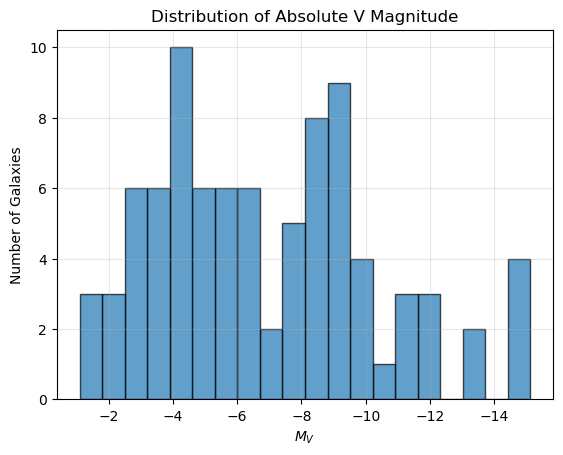

,key,ra,dec,name,host,confirmed_real,confirmed_galaxy,rhalf,rhalf_em,rhalf_ep,...,rhalf_physical_em,rhalf_physical_ep,rhalf_sph_physical,rhalf_sph_physical_em,rhalf_sph_physical_ep,surface_brightness_rhalf,distance_measurement_method,age,age_em,age_ep
0,antlia_2,143.807900,-36.699100,Antlia II,mw,1,1,104.6000,8.6000,8.6000,...,337.74,352.06,2379.32,247.72,248.01,30.72,NaN,NaN,NaN,NaN
1,aquarius_2,338.481300,-9.327400,Aquarius II,mw,1,1,5.1000,0.8000,0.8000,...,25.14,25.66,123.69,21.67,21.85,29.67,NaN,NaN,NaN,NaN
2,aquarius_3,357.218000,-3.489000,Aquarius III,mw,1,1,2.1000,0.5000,0.7000,...,14.77,15.20,36.28,12.68,13.78,28.87,NaN,NaN,NaN,NaN
3,bootes_1,210.020000,14.513500,Bootes I,mw,1,1,9.9700,0.2700,0.2700,...,8.63,8.97,160.86,8.04,8.28,28.58,NaN,NaN,NaN,NaN
4,bootes_2,209.514100,12.855300,Bootes II,mw,1,1,3.1700,0.4200,0.4200,...,5.12,5.22,33.00,5.03,5.02,28.22,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,leo_a,149.860417,30.746389,Leo A,NaN,1,1,2.3000,0.0900,0.0900,...,20.58,20.77,405.75,23.50,23.48,24.50,rrl,NaN,NaN,NaN
141,leo_k,141.025357,16.510577,Leo K,NaN,1,1,0.6367,0.0583,0.0633,...,7.58,7.65,61.68,5.84,5.93,27.79,NaN,NaN,NaN,NaN
142,leo_m,166.339300,25.345290,Leo M,NaN,1,1,0.9967,0.0350,0.0383,...,4.83,4.87,83.08,3.22,3.23,27.40,NaN,NaN,NaN,NaN
144,leo_t,143.722500,17.051389,Leo T,NaN,1,1,1.3900,0.2000,0.2000,...,23.68,23.89,155.06,23.04,22.81,26.54,NaN,NaN,NaN,NaN


In [4]:
# Load the data
dsph_mw = Table.read(
    'https://raw.githubusercontent.com/apace7/local_volume_database/main/data/dwarf_mw.csv'
).to_pandas()
dsph_m31 = Table.read(
    'https://raw.githubusercontent.com/apace7/local_volume_database/main/data/dwarf_m31.csv'
).to_pandas()
dsph_lf = Table.read(
    'https://raw.githubusercontent.com/apace7/local_volume_database/main/data/dwarf_local_field.csv'
).to_pandas()

# Concatenate all three dataframes (drop all-NA columns first)
dsph_combined = pd.concat([
    dsph_mw.dropna(axis=1, how='all'),
    dsph_m31.dropna(axis=1, how='all'),
    dsph_lf.dropna(axis=1, how='all')
], ignore_index=True)

# Filter for confirmed real galaxies within 800 kpc and M_V <= -15.5
dsph_filtered = dsph_combined[(dsph_combined['confirmed_real'] == 1) & 
                               (dsph_combined['confirmed_galaxy'] == 1) & 
                               (dsph_combined['M_V'] >= -15.5) & 
                               (dsph_combined['distance'] < 800)]

print(f"Total galaxies: {len(dsph_combined)}")
print(f"Filtered galaxies: {len(dsph_filtered)}")

plt.hist(dsph_filtered['M_V'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel(r'$M_V$')
plt.ylabel('Number of Galaxies')
plt.title('Distribution of Absolute V Magnitude')
plt.grid(alpha=0.3)
plt.gca().invert_xaxis()
plt.show()

dsph_filtered

In [5]:
verbose = False

syst_results = {}
for dsph in dsph_filtered.itertuples():
    if verbose:
        print(f"Processing {dsph.name}: M_V = {dsph.M_V:.2f}, D = {dsph.distance:.1f} kpc, rhalf = {dsph.rhalf:.2f} arcmin ({dsph.rhalf_sph_physical:.2f} pc), sigma_vlos = {dsph.vlos_sigma:.2f} km/s, M_Wolf = {10**dsph.mass_dynamical_wolf:.2e} Msun")
        print(f"  scaling # stars to match M_V...")
    phot_resampled = resample_phot_for_Mv(phot, dsph.M_V)
    
    # Shift by distance
    dm = 5.0 * np.log10(dsph.distance) + 10.0
    phot_apparent = phot_resampled.copy()
    phot_apparent['DECam_g'] += dm
    phot_apparent['DECam_r'] += dm
    phot_apparent['DECam_z'] += dm
    
    # Apply magnitude limits
    phot_sel = phot_apparent.loc[phot_apparent['DECam_z'] < z_cutoff].copy()
    if verbose:
        print(f"  Stars brighter than z={z_cutoff}: {len(phot_sel)}")
    
    # Sample x, y positions from a Plummer distribution
    if verbose:
        print(f"  Sampling spatial distribution (Plummer profile with rhalf={dsph.rhalf:.2f} arcmin)...")
    x, y = sample_plummer_2d(len(phot_sel), dsph.rhalf)
    phot_sel['x'] = x  # in arcmin
    phot_sel['y'] = y  # in arcmin
    
    # Select within FoV
    r = np.sqrt(phot_sel['x']**2 + phot_sel['y']**2)
    phot_fov = phot_sel[r < FoV / 2 * 60]
    if verbose:
        print(f"  Stars within FoV: {len(phot_fov)}")
    
    # Uniformly subsample to maximum target density (spatially uniform)
    phot_obs = uniform_spatial_subsample(phot_fov, n_fibers, FoV / 2 * 60)
    if verbose:
        print(f"  Final targets after spatial subsampling: {len(phot_obs)}")
    
    # Select within half-light radius
    r = np.sqrt(phot_obs['x']**2 + phot_obs['y']**2)
    phot_rhalf = phot_obs[r < dsph.rhalf]
    if verbose:
        print(f"  Stars within half-light radius: {len(phot_rhalf)}")
    
    # Calculate measurement errors for these stars
    results = compute_measurement_errors(phot_rhalf['DECam_z'], texp=texp, nexp=nexp)
    phot_rhalf["vrad_err"] = results['vrad_err']
    if verbose:
        print(f"  Median radial velocity error for stars within rhalf: {np.median(phot_rhalf['vrad_err']):.2f} km/s")
    
    # Calculate velocity dispersion error for this system
    sigma_vrad_err = compute_sigma_vrad_err(phot_rhalf["vrad_err"], dsph.vlos_sigma)
    if verbose:
        print(f"  Estimated velocity dispersion error: {sigma_vrad_err:.2f} km/s")
    
    # Calculate fractional Wolf mass error for this system
    frac_M_err = frac_wolf_mass_err(dsph.vlos_sigma, sigma_vrad_err, dsph.rhalf_sph_physical, 0)
    if verbose:
        print(f"  Fractional uncertainty on Wolf mass: {frac_M_err:.2f}")
    
    # Calculate Wolf mass error
    M_err = frac_M_err * 10**dsph.mass_dynamical_wolf
    if verbose:
        print(f"  Absolute uncertainty on Wolf mass: {M_err:.2e} Msun")
    
    syst_results[dsph.name] = {
        'M_V': dsph.M_V,
        'L_V': luminosity_from_Mv(dsph.M_V),
        'D': dsph.distance,
        'rhalf_arcmin': dsph.rhalf,
        'rhalf_sph_physical': dsph.rhalf_sph_physical,
        'M_dynamical_wolf': 10**dsph.mass_dynamical_wolf,
        'sigma_vrad': dsph.vlos_sigma,
        'sigma_vrad_err': sigma_vrad_err,
        'frac_M_err': frac_M_err,
        'M_err': M_err,
        'n_stars': len(phot_rhalf),
    }
dsph_forecasts = pd.DataFrame(syst_results).T
dsph_forecasts.to_csv("dsph_wolf_mass_forecasts.csv", index=True)


/Users/nathansandford/code/scratch/SpecS5/spec-s5-instrument/spec_s5_instrument/stellar_etc.py:250: UserWarning: 1573 magnitude(s) outside the gaia_dr5 data range [18.12, 20.26]. Extrapolating.
  warnings.warn(
/Users/nathansandford/code/scratch/SpecS5/spec-s5-instrument/spec_s5_instrument/stellar_etc.py:250: UserWarning: 12 magnitude(s) outside the gaia_dr5 data range [18.12, 20.26]. Extrapolating.
  warnings.warn(
/var/folders/l1/9w56xgdd6td5_qd0fv02hvfw0000gn/T/ipykernel_7717/3340754288.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phot_rhalf["vrad_err"] = results['vrad_err']
/Users/nathansandford/code/scratch/SpecS5/spec-s5-instrument/spec_s5_instrument/stellar_etc.py:250: UserWarning: 2 magnitude(s) outside the gaia_dr5 data range [18

/var/folders/l1/9w56xgdd6td5_qd0fv02hvfw0000gn/T/ipykernel_7717/2201778798.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


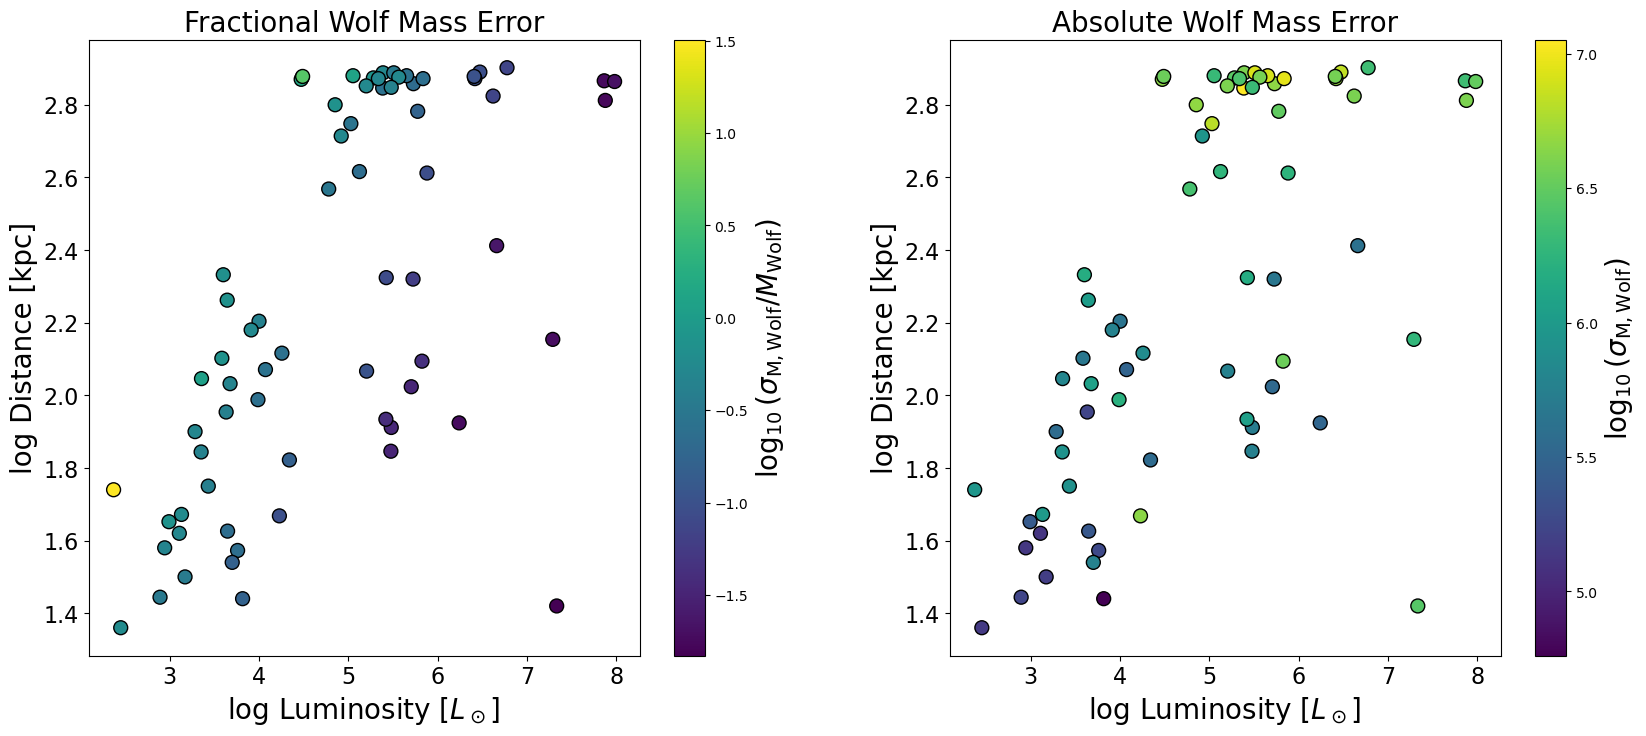

In [6]:
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# First panel: fractional Wolf mass error
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(
    np.log10(dsph_forecasts["L_V"]),
    np.log10(dsph_forecasts["D"]),
    c=np.log10(dsph_forecasts["frac_M_err"]),
    cmap='viridis', s=100, ec='k'
)
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label(r'$\log_{10}(\sigma_\mathrm{M,Wolf}/M_\mathrm{Wolf})$', fontsize=20)
ax1.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=20)
ax1.set_ylabel('log Distance [kpc]', fontsize=20)
ax1.tick_params(labelsize=16)
ax1.set_title("Fractional Wolf Mass Error", fontsize=20)

# Second panel: absolute Wolf mass error
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(
    np.log10(dsph_forecasts["L_V"]),
    np.log10(dsph_forecasts["D"]),
    c=np.log10(dsph_forecasts["M_err"]),
    cmap='viridis', s=100, ec='k'
)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label(r'$\log_{10}(\sigma_\mathrm{M,Wolf})$', fontsize=20)
ax2.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=20)
ax2.set_ylabel('log Distance [kpc]', fontsize=20)
ax2.tick_params(labelsize=16)
ax2.set_title("Absolute Wolf Mass Error", fontsize=20)

plt.tight_layout()
plt.show()

/var/folders/l1/9w56xgdd6td5_qd0fv02hvfw0000gn/T/ipykernel_7717/3844544410.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


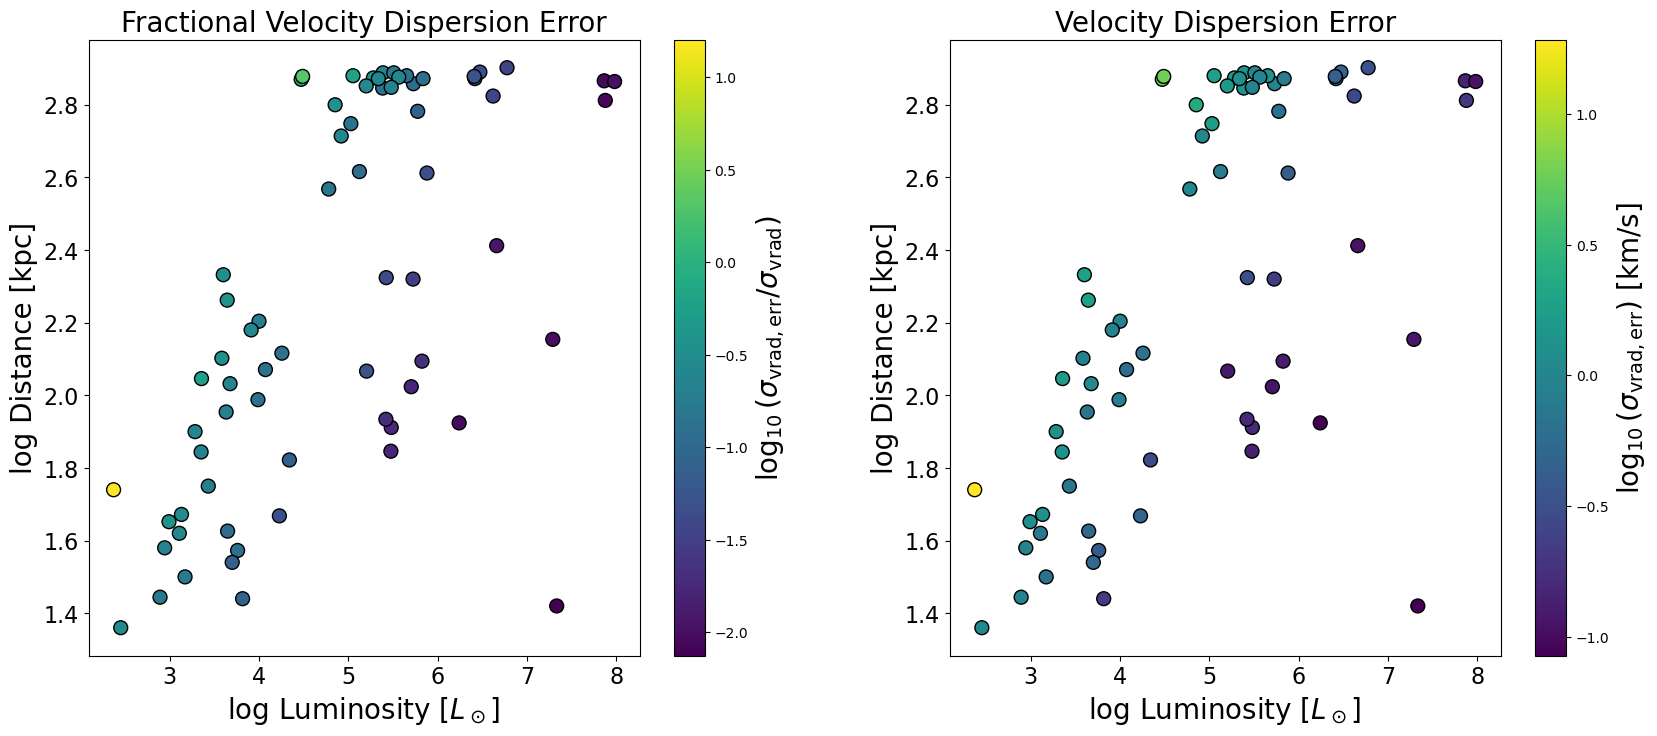

In [7]:
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# First panel: log10 fractional velocity dispersion error
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(
    np.log10(dsph_forecasts["L_V"]),
    np.log10(dsph_forecasts["D"]),
    c=np.log10(dsph_forecasts["sigma_vrad_err"] / dsph_forecasts["sigma_vrad"]),
    cmap='viridis', s=100, ec='k'
)
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label(r'$\log_{10}(\sigma_\mathrm{vrad,err}/\sigma_\mathrm{vrad})$', fontsize=20)
ax1.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=20)
ax1.set_ylabel('log Distance [kpc]', fontsize=20)
ax1.tick_params(labelsize=16)
ax1.set_title("Fractional Velocity Dispersion Error", fontsize=20)

# Second panel: log10 absolute velocity dispersion error
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(
    np.log10(dsph_forecasts["L_V"]),
    np.log10(dsph_forecasts["D"]),
    c=np.log10(dsph_forecasts["sigma_vrad_err"]),
    cmap='viridis', s=100, ec='k'
)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label(r'$\log_{10}(\sigma_\mathrm{vrad,err})$ [km/s]', fontsize=20)
ax2.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=20)
ax2.set_ylabel('log Distance [kpc]', fontsize=20)
ax2.tick_params(labelsize=16)
ax2.set_title("Velocity Dispersion Error", fontsize=20)

plt.tight_layout()
plt.show()

/Users/nathansandford/miniforge3/envs/mwsb1b/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/l1/9w56xgdd6td5_qd0fv02hvfw0000gn/T/ipykernel_7717/2555432077.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


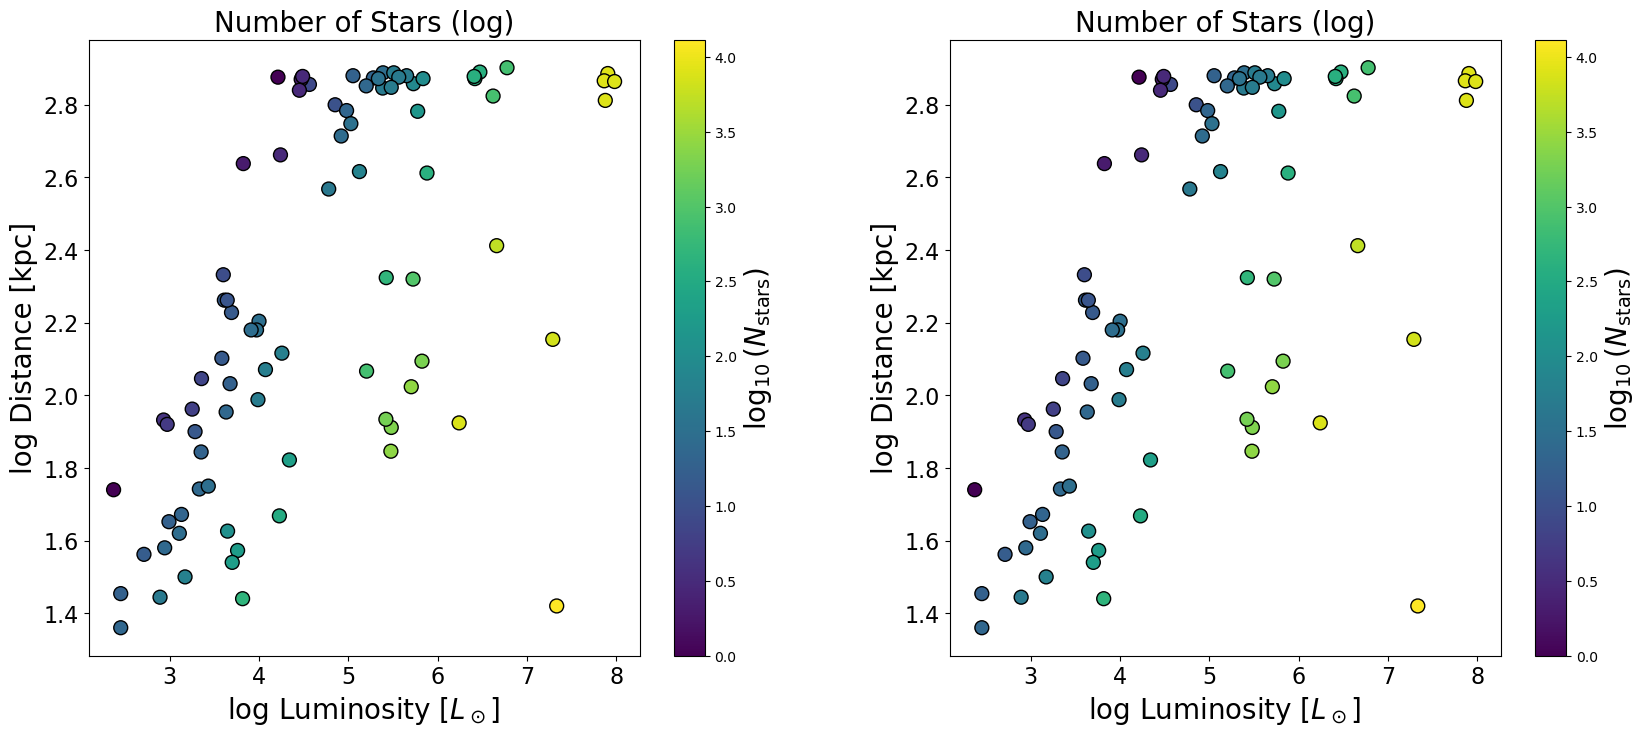

In [8]:
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# First panel: log10 number of stars
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(
    np.log10(dsph_forecasts["L_V"]),
    np.log10(dsph_forecasts["D"]),
    c=np.log10(dsph_forecasts["n_stars"]),
    cmap='viridis', s=100, ec='k'
)
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label(r'$\log_{10}(N_\mathrm{stars})$', fontsize=20)
ax1.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=20)
ax1.set_ylabel('log Distance [kpc]', fontsize=20)
ax1.tick_params(labelsize=16)
ax1.set_title("Number of Stars (log)", fontsize=20)

# Second panel: log10 number of stars (same as first, but you can change axes if desired)
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(
    np.log10(dsph_forecasts["L_V"]),
    np.log10(dsph_forecasts["D"]),
    c=np.log10(dsph_forecasts["n_stars"]),
    cmap='viridis', s=100, ec='k'
)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label(r'$\log_{10}(N_\mathrm{stars})$', fontsize=20)
ax2.set_xlabel(r'log Luminosity [$L_\odot$]', fontsize=20)
ax2.set_ylabel('log Distance [kpc]', fontsize=20)
ax2.tick_params(labelsize=16)
ax2.set_title("Number of Stars (log)", fontsize=20)

plt.tight_layout()
plt.show()

/var/folders/l1/9w56xgdd6td5_qd0fv02hvfw0000gn/T/ipykernel_7717/1776997371.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


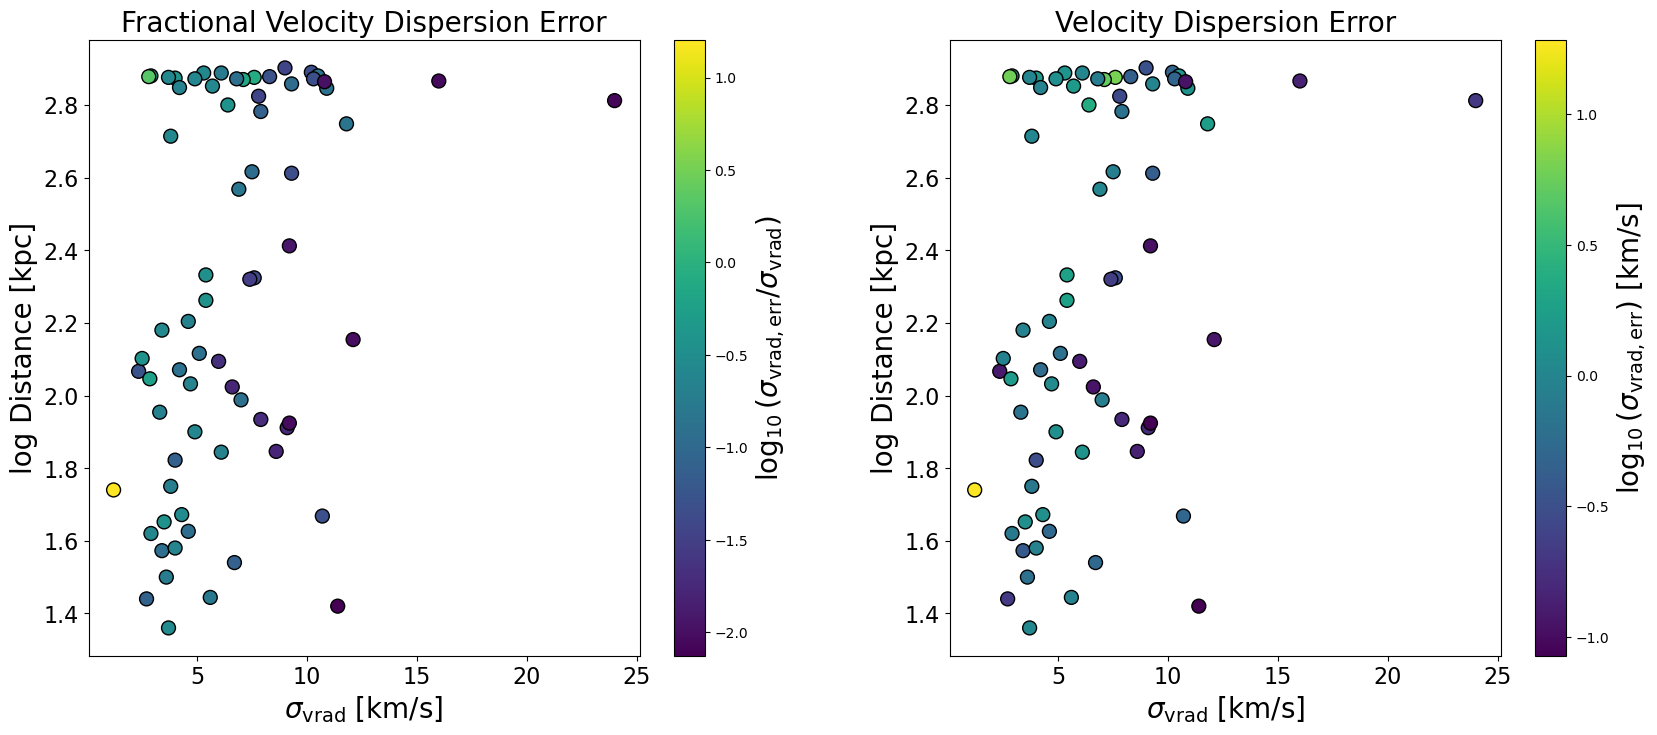

In [9]:
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)

# First panel: log10 fractional velocity dispersion error
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(
    dsph_forecasts["sigma_vrad"],
    np.log10(dsph_forecasts["D"]),
    c=np.log10(dsph_forecasts["sigma_vrad_err"] / dsph_forecasts["sigma_vrad"]),
    cmap='viridis', s=100, ec='k'
)
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label(r'$\log_{10}(\sigma_\mathrm{vrad,err}/\sigma_\mathrm{vrad})$', fontsize=20)
ax1.set_xlabel(r'$\sigma_\mathrm{vrad}$ [km/s]', fontsize=20)
ax1.set_ylabel('log Distance [kpc]', fontsize=20)
ax1.tick_params(labelsize=16)
ax1.set_title("Fractional Velocity Dispersion Error", fontsize=20)

# Second panel: log10 absolute velocity dispersion error
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(
    dsph_forecasts["sigma_vrad"],
    np.log10(dsph_forecasts["D"]),
    c=np.log10(dsph_forecasts["sigma_vrad_err"]),
    cmap='viridis', s=100, ec='k'
)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label(r'$\log_{10}(\sigma_\mathrm{vrad,err})$ [km/s]', fontsize=20)
ax2.set_xlabel(r'$\sigma_\mathrm{vrad}$ [km/s]', fontsize=20)
ax2.set_ylabel('log Distance [kpc]', fontsize=20)
ax2.tick_params(labelsize=16)
ax2.set_title("Velocity Dispersion Error", fontsize=20)

plt.tight_layout()
plt.show()